# Oscar Nomination Prediction - Model Testing

This notebook evaluates a trained transformer model on the test dataset to predict whether movie scripts were nominated for an Oscar.

**Binary Classification Task:**
- **0**: Not nominated for Oscar
- **1**: Nominated for Oscar

The notebook will:
1. Load a specific model predictions on the test dataset
3. Calculate accuracy metrics
4. Visualize test results with confusion matrix, etc.

In [1]:
import os
from pathlib import Path
import json

import numpy as np

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd

import torch


In [2]:
# ── Plot style ────────────────────────────────────────────────────────────────
plt.style.use('ggplot')
# plt.style.use('seaborn-v0_8-whitegrid')

mpl.rcParams.update({
    # Typography
    'font.family':        'Ubuntu Sans',
    'axes.titlesize':     14,
    # 'axes.titleweight':   'bold',
    'axes.labelsize':     12,
    'xtick.labelsize':    10,
    'ytick.labelsize':    10,
    'legend.fontsize':    10,
    'text.color':          'black',
    'axes.titlecolor':     'black',
    'axes.labelcolor':     'black',
    'legend.labelcolor':   'black',
    'xtick.color':         'black',
    'ytick.color':         'black',

    # Figure
    'figure.dpi':         120,
    'figure.facecolor':   'white',

    # Colors
    'axes.prop_cycle': mpl.cycler(color=[
        '#2563EB', '#DC2626', '#16A34A', '#D97706', '#7C3AED'
    ]),
})

ACCENT   = '#2563EB'   # primary blue
ACCENT2  = '#DC2626'   # red (operating point, etc.)
BASELINE = '#94A3B8'   # slate-gray for diagonal / random lines

## Load Test Dataset

In [3]:
processed_dir = os.path.join('..','data', 'processed')
df_test = pd.read_parquet(os.path.join(processed_dir,'test_clean.parquet'))
df_test.head()

,movie_name,imdb_id,title,year,summary,script,script_plain,script_clean,nominated,winner
0,Blades of Glory_2007,tt0445934,Blades of Glory,2007,"At the 2002 World Winter Sport Games, raunchy ...",<script>\n <scene />\n <scene>\n <stage_d...,"\n \n \n ...\_\_,.~. .,/\\ \n Bla...","...\_\_,.~. .,/\\\nBlades Of Glory By John Alt...",0,0
1,Room_2015,tt3170832,Room,2015,"In Akron, Ohio, 24-year-old Joy Newsome and he...",<script>\n <scene>\n <scene_description>Ro...,\n \n Room Written by Emma Donoghue Bas...,Room Written by Emma Donoghue Based on the nov...,1,0
2,Uncut Gems_2019,tt5727208,Uncut Gems,2019,"In 2010, Ethiopian Jewish miners retrieve a ra...",<script>\n <scene>\n <character>UNCUT GEMS...,\n \n UNCUT GEMS \n by \n SAFDI...,UNCUT GEMS\nby\nSAFDIE &amp; BRONSTEIN\nIN HOW...,0,0
3,Kundun_1997,tt0119485,Kundun,1997,The film has a linear chronology with events s...,<script>\n <scene>\n <stage_direction>KUND...,\n \n KUNDUN \n The Himalayas . A s...,"KUNDUN\nThe Himalayas . A still photograph , a...",0,0
4,MASH_1970,tt0066026,MASH,1970,"In 1951, the 4077th Mobile Army Surgical Hospi...",<script>\n <scene>\n <stage_direction>EXT....,\n \n EXT. LANDING AREA IUTSIDE 4077th ...,EXT. LANDING AREA IUTSIDE 4077th MASH - DAY\nO...,1,1


## Model Configuration

Set the path to the model config

In [ ]:
config_path = '../models/best_results/best_gpt_agg_config.json'

# Pick which variant's checkpoint/results to inspect.
# Keep this consistent with the results_file selection in the next cell.
variant = 'best_f1'   # or 'best_auc' / 'best_loss'

In [5]:
with open(config_path, 'r') as f:
    cfg = json.load(f)

data_cfg = cfg['data']
model_cfg = cfg['model']
training_cfg = cfg['training']

checkpoint_prefix = training_cfg.get('checkpoint_prefix', 'model')

models_dir = Path(training_cfg.get('models_dir', '../models')) / training_cfg['sub_dir']
results_dir = Path(training_cfg.get('results_dir', '../results')) / training_cfg['sub_dir']

In [6]:
ckpt_path = models_dir / f"{checkpoint_prefix}_{variant}.pth"
ckpt = torch.load(ckpt_path, map_location='cpu', weights_only=False)

if 'val_threshold' in ckpt:
    threshold = float(ckpt['val_threshold'])
    threshold_source = 'checkpoint_val_threshold'
    print(f"Using validation-tuned threshold: {threshold:.4f}  (from {ckpt_path.name})")
else:
    threshold = 0.5
    threshold_source = 'default'
    print(f"WARNING: no 'val_threshold' in {ckpt_path.name}. Falling back to threshold = 0.5")

Using validation-tuned threshold: 0.4800  (from gpt_agg_sm4_best_f1.pth)


## Load Test Dataset Predictions

In [7]:
# results_file = results_dir / f"{checkpoint_prefix}_test_results.json"

results_file = results_dir / f"{checkpoint_prefix}_{variant}_test_results.json"

print(results_file)
with open(results_file, 'r') as f:
    results_dict = json.load(f,)

results_df = pd.DataFrame(data=results_dict)
results_df.head()

../results/260503_runs/gpt_agg_sm4_best_f1_test_results.json


,idx,imdb_id,target,model_prediction,model_prob
0,0,tt0445934,0,0,0.284974
1,1,tt3170832,1,0,0.325521
2,2,tt5727208,0,0,0.287368
3,3,tt0119485,0,1,0.984094
4,4,tt0066026,1,1,0.899828


In [8]:
all_targets = results_df['target'].to_list()
all_probabilities = results_df['model_prob'].to_list()

# Recompute predictions from probabilities using the loaded threshold.
# This ensures the notebook reflects `threshold` even if `model_prediction`
# in the JSON came from an older test run that used 0.5/argmax.
all_predictions = [1 if p >= threshold else 0 for p in all_probabilities]

# sanity check vs JSON
json_preds = results_df['model_prediction'].to_list()
mismatches = sum(a != b for a, b in zip(all_predictions, json_preds))
print(f"Recomputed predictions at threshold={threshold:.3f} "
      f"({threshold_source}); {mismatches} differ from JSON's model_prediction.")

Recomputed predictions at threshold=0.480 (checkpoint_val_threshold); 0 differ from JSON's model_prediction.


In [9]:
results_df[(results_df['target'] == 1) & (results_df['model_prediction'] == 1)].head()

,idx,imdb_id,target,model_prediction,model_prob
4,4,tt0066026,1,1,0.899828
17,17,tt4302938,1,1,0.624752
28,28,tt0069704,1,1,0.686790
39,39,tt2024544,1,1,0.959762
43,43,tt0092699,1,1,0.988492


## Generate Confusion Matrix

Visualize the model's performance by showing:
- **True Negatives**: Correctly predicted not nominated
- **False Positives**: Incorrectly predicted nominated
- **False Negatives**: Incorrectly predicted not nominated
- **True Positives**: Correctly predicted nominated

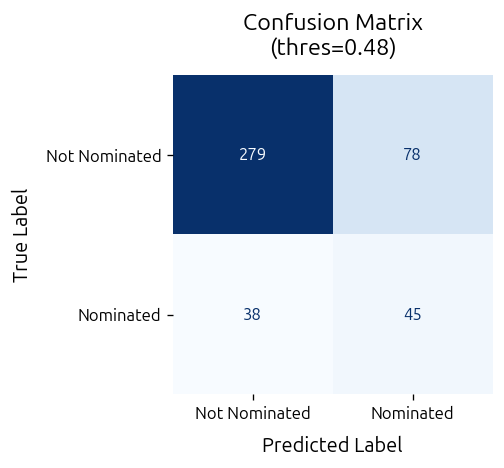

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(all_targets, all_predictions)

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not Nominated', 'Nominated']
)
disp.plot(cmap='Blues', values_format='d', ax=ax, colorbar=False)
ax.grid(False)
ax.set_title(
    f'Confusion Matrix\n(thres={threshold:.2f})',
    pad=12
)
ax.set_xlabel('Predicted Label', labelpad=8)
ax.set_ylabel('True Label', labelpad=8)
# lighten inner grid lines that ConfusionMatrixDisplay draws
for spine in ax.spines.values():
    spine.set_visible(False)
fig.tight_layout()
plt.show()

## ROC Curve and AUC

The **ROC (Receiver Operating Characteristic) curve** plots the trade-off between:
- **True Positive Rate (TPR)**: Sensitivity - how many actual positives are correctly identified
- **False Positive Rate (FPR)**: How many actual negatives are incorrectly classified as positive

The **AUC (Area Under the Curve)** summarizes the ROC curve into a single metric:
- **AUC = 1.0**: Perfect classifier
- **AUC = 0.5**: Random classifier (no better than chance)
- **AUC < 0.5**: Worse than random (predictions are inverted)

A higher AUC indicates better model performance at distinguishing between nominated and non-nominated scripts.


Computing ROC curve and AUC...
AUC Score: 0.698


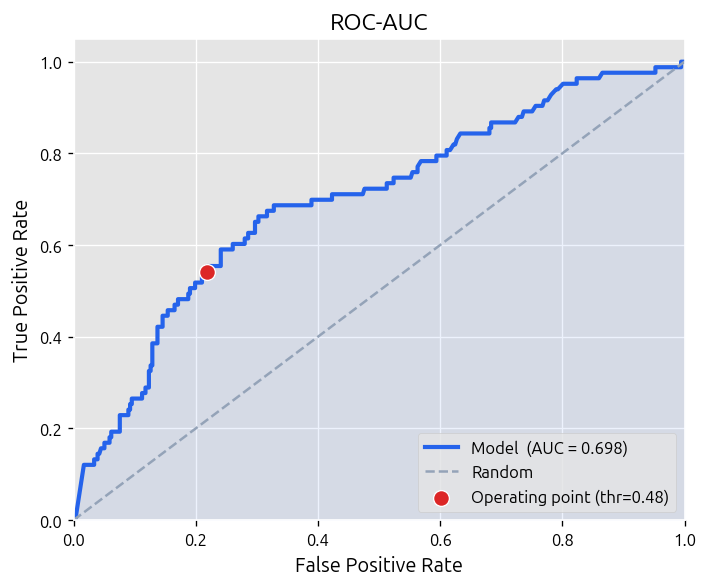

In [11]:
print("\nComputing ROC curve and AUC...")

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(all_targets, all_probabilities)

# Compute Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

print(f"AUC Score: {roc_auc:.3f}")

# mark operating point at the loaded threshold
probs_arr = np.asarray(all_probabilities)
targets_arr = np.asarray(all_targets)
op_preds = (probs_arr >= threshold).astype(int)
P = targets_arr.sum()
N = len(targets_arr) - P
op_tpr = ((op_preds == 1) & (targets_arr == 1)).sum() / max(P, 1)
op_fpr = ((op_preds == 1) & (targets_arr == 0)).sum() / max(N, 1)

# Plot ROC curve
fig, ax = plt.subplots(figsize=(6, 5))

ax.plot(fpr, tpr, color=ACCENT, lw=2.5,
        label=f'Model  (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color=BASELINE, lw=1.5, linestyle='--',
        label='Random')
ax.scatter([op_fpr], [op_tpr], color=ACCENT2, zorder=5, s=90,
           edgecolors='white', linewidths=0.8,
           label=f'Operating point (thr={threshold:.2f})')
ax.fill_between(fpr, tpr, alpha=0.08, color=ACCENT)

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC-AUC')
ax.legend(loc='lower right')
fig.tight_layout()

plt.show()

## Classification Metrics Summary

Comprehensive evaluation metrics for binary classification:

- **Accuracy**: Overall percentage of correct predictions (both classes)
- **Precision**: Of all predicted nominations, what percentage were actually nominated? (TP / (TP + FP))
- **Recall**: Of all actual nominations, what percentage did we correctly identify? (TP / (TP + FN))
- **F1 Score**: Harmonic mean of precision and recall, balancing both metrics
- **Macro-F1**: Average of F1 scores for both classes, treating them equally regardless of class imbalance

In [12]:
print("\nComputing classification metrics...")

# Calculate metrics
acc = accuracy_score(all_targets, all_predictions)
precision = precision_score(all_targets, all_predictions, average='binary', pos_label=1)
recall = recall_score(all_targets, all_predictions, average='binary', pos_label=1)
f1 = f1_score(all_targets, all_predictions, average='binary', pos_label=1)
macro_f1 = f1_score(all_targets, all_predictions, average='macro')

# Create DataFrame
metrics_df = pd.DataFrame({
    'Metric': ['Threshold', 'Threshold Source',
               'Accuracy', 'Precision', 'Recall', 'F1 Score', 'Macro-F1'],
    'Value':  [threshold, threshold_source,
               acc, precision, recall, f1, macro_f1]
})

# Format values as percentages
def _fmt(row):
    metric = row['Metric']
    v = row['Value']
    if metric == 'Threshold':
        return f'{float(v):.4f}'
    if metric == 'Threshold Source':
        return str(v)
    return f'{v:.3f}'

metrics_df['Score'] = metrics_df.apply(_fmt, axis=1)

# Display the table
print("\nClassification Metrics:")
print("=" * 50)
display(metrics_df[['Metric', 'Score']])
print("=" * 50)


Computing classification metrics...

Classification Metrics:


,Metric,Score
0,Threshold,0.4800
1,Threshold Source,checkpoint_val_threshold
2,Accuracy,0.736
3,Precision,0.366
4,Recall,0.542
5,F1 Score,0.437
6,Macro-F1,0.632


## Movie Analysis

Identify which Oscar-nominated movies (true label = 1) were correctly predicted by the model as nominated (predicted = 1).

This shows us which nominated scripts the model successfully identified as having Oscar-worthy characteristics.

In [13]:
def _fmt(row):
    v = row['prob_nominated']
    return f'{float(v) * 100:.1f}%'

# Find indices where true label = 1 AND predicted label = 1 (True Positives)
tp_indices = [i for i in range(len(all_targets)) if all_targets[i] == 1 and all_predictions[i] == 1]
fp_indices = [i for i in range(len(all_targets)) if all_targets[i] == 0 and all_predictions[i] == 1]
fn_indices = [i for i in range(len(all_targets)) if all_targets[i] == 1 and all_predictions[i] == 0]

# Filter df_test by TP indices and show title, year, summary
tp_movies = df_test.iloc[tp_indices][['title', 'year']].reset_index(drop=True)
tp_movies['prob_nominated'] = [all_probabilities[i] for i in tp_indices]
tp_movies = tp_movies.sort_values(by='year').reset_index(drop=True)
tp_movies['prob_nominated'] = tp_movies.apply(_fmt, axis=1)

print(f"\n{'='*80}")
print("Movies Correctly Predicted as Oscar Nominated (True Positives):")
print(f"{'='*80}\n")

# Display the dataframe
display(tp_movies)


Movies Correctly Predicted as Oscar Nominated (True Positives):



,title,year,prob_nominated
0,The Grapes of Wrath,1940,98.8%
1,It's a Wonderful Life,1946,98.9%
2,Some Like It Hot,1959,98.0%
3,The Hustler,1961,98.5%
4,The Battle of Algiers,1966,92.5%
5,The Graduate,1967,70.6%
6,MASH,1970,90.0%
7,The Godfather,1972,98.3%
8,American Graffiti,1973,68.7%
9,Young Frankenstein,1974,98.8%


In [14]:
fp_movies = df_test.iloc[fp_indices][['title', 'year']].reset_index(drop=True)
fp_movies['prob_nominated'] = [all_probabilities[i] for i in fp_indices]
fp_movies = fp_movies.sort_values(by='year').reset_index(drop=True)
fp_movies['prob_nominated'] = fp_movies.apply(_fmt, axis=1)

print(f"\n{'='*80}")
print("Movies Model Thinks Did Deserve Oscar Nomination but Didn't (False Positives):")
print(f"{'='*80}\n")

# Display the dataframe
display(fp_movies)


Movies Model Thinks Did Deserve Oscar Nomination but Didn't (False Positives):



,title,year,prob_nominated
0,His Girl Friday,1940,98.8%
1,Jane Eyre,1943,98.8%
2,Tall in the Saddle,1944,54.6%
3,The Big Sleep,1946,57.5%
4,Portrait of Jennie,1948,98.8%
...,...,...,...
73,The Son,2022,96.9%
74,Armageddon Time,2022,92.8%
75,Weird: The Al Yankovic Story,2022,85.8%
76,Nyad,2023,49.7%


In [15]:
fn_movies = df_test.iloc[fn_indices][['title', 'year']].reset_index(drop=True)
fn_movies['prob_nominated'] = [all_probabilities[i] for i in fn_indices]
fn_movies = fn_movies.sort_values(by='year').reset_index(drop=True)
fn_movies['prob_nominated'] = fn_movies.apply(_fmt, axis=1)

print(f"\n{'='*80}")
print("Movies Model Thinks Didn't Deserve Oscar Nomination but Did (False Negative):")
print(f"{'='*80}\n")

# Display the dataframe
display(fn_movies)


Movies Model Thinks Didn't Deserve Oscar Nomination but Did (False Negative):



,title,year,prob_nominated
0,To Kill a Mockingbird,1962,44.7%
1,Klute,1971,34.2%
2,Taxi Driver,1976,29.9%
3,Raging Bull,1980,31.6%
4,Gandhi,1982,33.4%
5,JFK,1991,44.8%
6,Braveheart,1995,26.4%
7,The Usual Suspects,1995,41.5%
8,Shine,1996,31.8%
9,Gangs of New York,2002,29.7%
